In [ ]:
#INTEGRANTES DO TRIO: DÉBORA RUBIO, NATALIA THOMAZELLI, PAULO FONSECA

In [ ]:
# 1. Importar bibliotecas

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
# 2. Fazer upload do arquivo Excel

from google.colab import files

arquivo = files.upload()

Saving pacientes_diabetes_10.xlsx to pacientes_diabetes_10 (5).xlsx


In [ ]:
# 3. Ler o arquivo Excel

df = pd.read_excel("pacientes_diabetes_10.xlsx")

# Remover linhas com valores NaN na coluna 'Outcome', que correspondem a legendas e observações
df = df.dropna(subset=['Outcome'])

df

,Paciente_ID,Gestacoes,Glicose_mg_dL,Pressao_mmHg,Insulina_uU_mL,IMC,Historico_Familiar,Idade,Outcome
0,P001,2,168.0,72.0,145.0,33.6,0.63,42.0,1.0
1,P002,5,154.0,78.0,180.0,35.2,0.81,51.0,1.0
2,P003,1,142.0,70.0,125.0,31.4,0.47,36.0,1.0
3,P004,7,176.0,84.0,210.0,38.1,1.02,55.0,1.0
4,P005,3,160.0,76.0,165.0,34.7,0.72,47.0,1.0
5,P006,4,149.0,82.0,155.0,36.3,0.58,44.0,1.0
6,P007,1,92.0,66.0,80.0,24.8,0.21,25.0,0.0
7,P008,0,105.0,68.0,90.0,27.1,0.29,29.0,0.0
8,P009,2,112.0,72.0,98.0,28.6,0.34,33.0,0.0
9,P010,1,99.0,64.0,75.0,25.9,0.18,27.0,0.0


In [ ]:
# 5. Separar as variáveis de entrada e a variável de saída

X = df.drop(columns=["Paciente_ID", "Outcome"])

y = df["Outcome"]

print("Variáveis utilizadas:")
print(X.columns)

print("\nDiagnóstico:")
print(y)

Variáveis utilizadas:
Index(['Gestacoes', 'Glicose_mg_dL', 'Pressao_mmHg', 'Insulina_uU_mL', 'IMC',
       'Historico_Familiar', 'Idade'],
      dtype='object')

Diagnóstico:
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
5    1.0
6    0.0
7    0.0
8    0.0
9    0.0
Name: Outcome, dtype: float64


In [ ]:
# 6. Verificar colisões de registros

colunas_entrada = X.columns.tolist()

colisoes = df.groupby(colunas_entrada)["Outcome"].nunique()

colisoes = colisoes[colisoes > 1]

if len(colisoes) == 0:
    print("Não foram encontradas colisões.")
else:
    print("Foram encontradas colisões:")
    print(colisoes)

Não foram encontradas colisões.


In [ ]:
# 7. Criar a árvore sem limite de profundidade

arvore_completa = DecisionTreeClassifier(
    random_state=42
)

# Treinar o modelo
arvore_completa.fit(X, y)

DecisionTreeClassifier(random_state=42)

In [ ]:
arvore_completa.fit(X, y)

DecisionTreeClassifier(random_state=42)

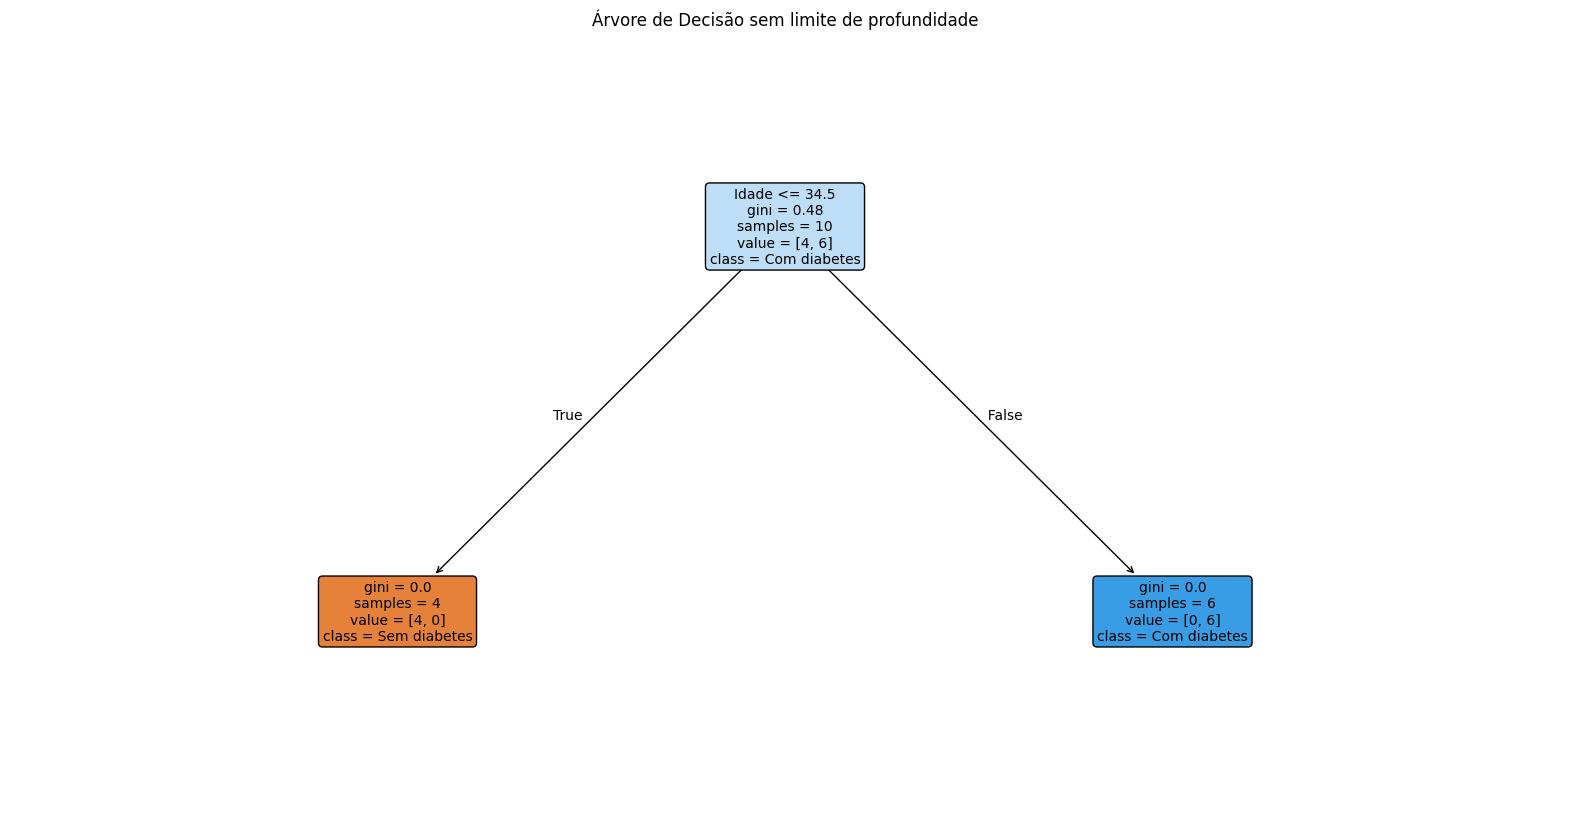

In [ ]:
# 8. Mostrar a árvore completa

plt.figure(figsize=(20, 10))

plot_tree(
    arvore_completa,
    feature_names=X.columns,
    class_names=["Sem diabetes", "Com diabetes"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árvore de Decisão sem limite de profundidade")

plt.show()

In [ ]:
# 9. Informações da árvore completa

print("Profundidade da árvore:", arvore_completa.get_depth())
print("Quantidade de folhas:", arvore_completa.get_n_leaves())

Profundidade da árvore: 1
Quantidade de folhas: 2


In [ ]:
# 10. Probabilidades da árvore completa

probabilidades_completa = arvore_completa.predict_proba(X)

probabilidades_completa

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [ ]:
# Criar uma tabela com as probabilidades

resultado_completa = pd.DataFrame({
    "Paciente": df["Paciente_ID"],
    "Prob_Sem_Diabetes": probabilidades_completa[:, 0],
    "Prob_Com_Diabetes": probabilidades_completa[:, 1]
})

resultado_completa

,Paciente,Prob_Sem_Diabetes,Prob_Com_Diabetes
0,P001,0.0,1.0
1,P002,0.0,1.0
2,P003,0.0,1.0
3,P004,0.0,1.0
4,P005,0.0,1.0
5,P006,0.0,1.0
6,P007,1.0,0.0
7,P008,1.0,0.0
8,P009,1.0,0.0
9,P010,1.0,0.0


In [ ]:
max_depth=3

In [ ]:
# 11. Criar árvore limitada a profundidade 3

arvore_depth3 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

arvore_depth3.fit(X, y)

DecisionTreeClassifier(max_depth=3, random_state=42)

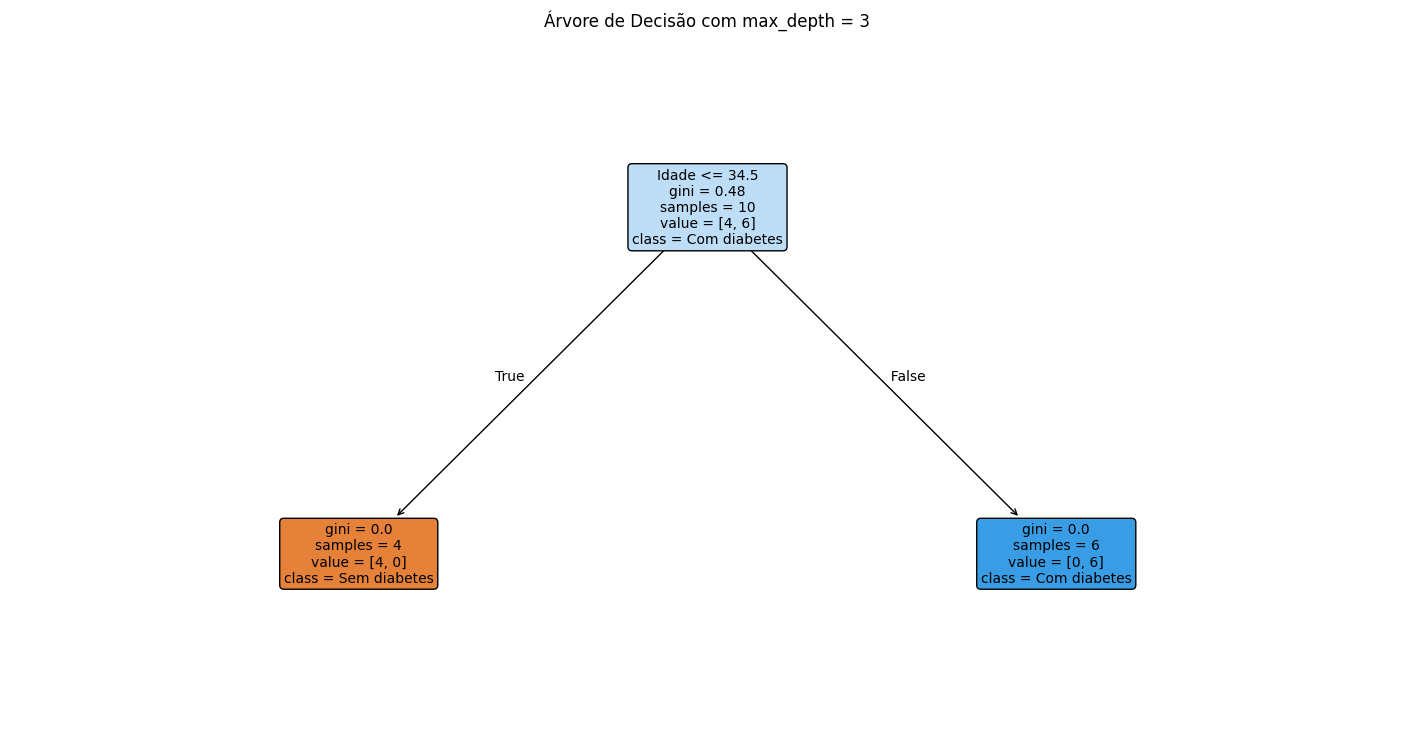

In [ ]:
# 12. Mostrar árvore com max_depth = 3

plt.figure(figsize=(18, 9))

plot_tree(
    arvore_depth3,
    feature_names=X.columns,
    class_names=["Sem diabetes", "Com diabetes"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árvore de Decisão com max_depth = 3")

plt.show()

In [ ]:
# 13. Informações da árvore limitada

print("Profundidade:", arvore_depth3.get_depth())
print("Quantidade de folhas:", arvore_depth3.get_n_leaves())

Profundidade: 1
Quantidade de folhas: 2


In [ ]:
# 14. Probabilidades da árvore com max_depth = 3

probabilidades_depth3 = arvore_depth3.predict_proba(X)

resultado_depth3 = pd.DataFrame({
    "Paciente": df["Paciente_ID"],
    "Prob_Sem_Diabetes": probabilidades_depth3[:, 0],
    "Prob_Com_Diabetes": probabilidades_depth3[:, 1]
})

resultado_depth3

,Paciente,Prob_Sem_Diabetes,Prob_Com_Diabetes
0,P001,0.0,1.0
1,P002,0.0,1.0
2,P003,0.0,1.0
3,P004,0.0,1.0
4,P005,0.0,1.0
5,P006,0.0,1.0
6,P007,1.0,0.0
7,P008,1.0,0.0
8,P009,1.0,0.0
9,P010,1.0,0.0


In [ ]:
# 15. Comparar probabilidades dos dois modelos

comparacao = pd.DataFrame({
    "Paciente": df["Paciente_ID"],

    "Real": y,

    "Prob_Diabetes_Arvore_Completa":
        probabilidades_completa[:, 1],

    "Prob_Diabetes_MaxDepth3":
        probabilidades_depth3[:, 1]
})

comparacao

,Paciente,Real,Prob_Diabetes_Arvore_Completa,Prob_Diabetes_MaxDepth3
0,P001,1.0,1.0,1.0
1,P002,1.0,1.0,1.0
2,P003,1.0,1.0,1.0
3,P004,1.0,1.0,1.0
4,P005,1.0,1.0,1.0
5,P006,1.0,1.0,1.0
6,P007,0.0,0.0,0.0
7,P008,0.0,0.0,0.0
8,P009,0.0,0.0,0.0
9,P010,0.0,0.0,0.0


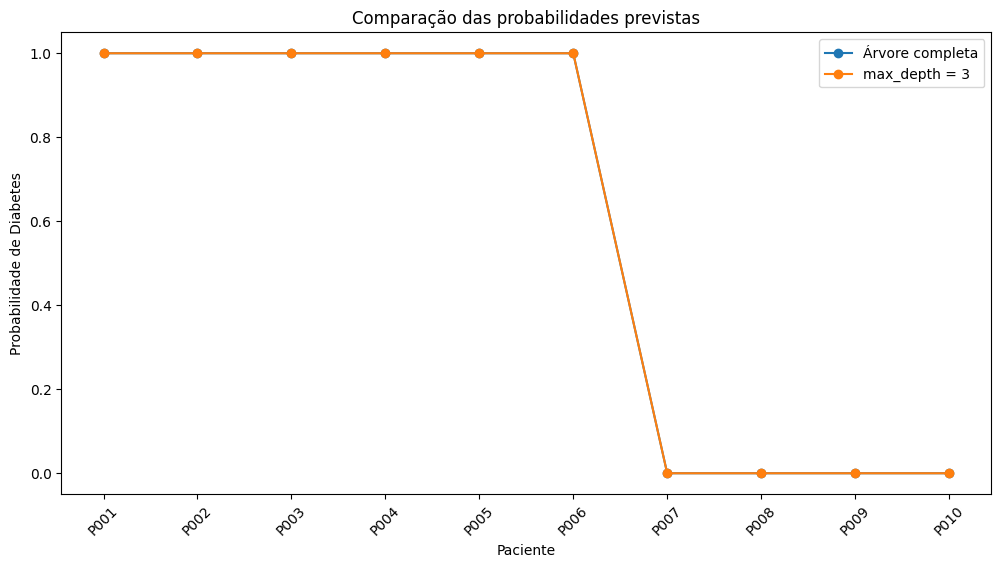

In [ ]:
# 16. Gráfico comparando as probabilidades

plt.figure(figsize=(12, 6))

plt.plot(
    comparacao["Paciente"],
    comparacao["Prob_Diabetes_Arvore_Completa"],
    marker="o",
    label="Árvore completa"
)

plt.plot(
    comparacao["Paciente"],
    comparacao["Prob_Diabetes_MaxDepth3"],
    marker="o",
    label="max_depth = 3"
)

plt.xlabel("Paciente")
plt.ylabel("Probabilidade de Diabetes")
plt.title("Comparação das probabilidades previstas")

plt.legend()

plt.xticks(rotation=45)

plt.show()